In [1]:
import sys
sys.path.append('../')
import UTILS.utils as utils
import cv2
import pandas as pd
import json

# DESCRIBING IMAGES

In [ ]:
# GET IMAGE CAPTIONS FROM BOOK
sentence_folders = utils.get_folders_in_folder("../../Data/TEXT/ALL_SENTENCES/")
all_captions = []
for folder in sentence_folders:
    all_paragraphs = utils.get_files_in_directory(folder + "/")
    first_paragraph = utils.read_file(all_paragraphs[0])
    caption = first_paragraph.split("\n")[0]
    if caption[0].isdigit():
        caption = ".".join(caption.split(".")[1:])
    all_captions.append(caption)

In [7]:
# GENERATE PROMPT FOR DESCRIBING IMAGE
def get_prompt(caption):
    prompt = "The following image is captioned '" + caption + "'"
    prompt += "Please provide a detailed description of the scene that it shows (not on the photography angle or on the quality of the photograph). Only provide the detailed description, no other comments."
    return prompt

In [8]:
import google.generativeai as genai

genai.configure(api_key=utils.API_KEY())
model = genai.GenerativeModel('gemini-1.5-flash')

In [9]:
def prompt_model(file, prompt, image_num):
    response = model.generate_content(
    contents=[
        file,
        prompt])
    f = open("../../Data/STEREO_VIEWS/DESCRIPTIONS/image_" + str(image_num+1) + ".txt", "x")
    f.write(response.text)
    f.close()
    return response.text

In [10]:
all_images = utils.get_files_in_directory("../../Data/STEREO_VIEWS/LEFT_IMAGE/")

In [11]:
from tqdm import tqdm

def get_gemini_image_descriptions(captions, images):
    captions_and_images = [list(a) for a in zip(captions, images)]
    for i, x in tqdm(enumerate(captions_and_images)):
        sample_file = genai.upload_file(path=x[1], display_name="file1")
        prompt = get_prompt(x[0])
        prompt_model(sample_file, prompt, i)

#get_gemini_image_descriptions(all_captions, all_images)

In [ ]:
# remove unnecessary comments from description

all_descriptions = utils.get_files_in_directory("../../Data/STEREO_VIEWS/DESCRIPTIONS/")
filtered_descriptions = []
for i, description in enumerate(all_descriptions):
    description_text = utils.read_file(description)
    description_lines = [a for a in description_text.split("\n") if len(a) > 0]
    description_lines = [a for a in description_lines if not "here is a description" in a.lower() and not "here is a detailed description" in a.lower()]
    description_lines = [a for a in description_lines if not "here's a description" in a.lower()]
    final = " ".join(description_lines)
    filtered_descriptions.append({"image" : (i+1), "description" : final})

#pd.DataFrame.from_dict(filtered_descriptions).to_csv("../../Data/STEREO_VIEWS/IMAGE_DESCRIPTIONS.csv")

# LABELING IMAGES

In [14]:
def create_huge_prompt(df):
    prompt = "Your task will be to distill a list of topics from the following documents: \n"
    for text in df["description"].to_list():
        prompt += "DOCUMENT: {" + text + "}\n"
    prompt += """
    Your response should be a JSON in the following format: {‘topics’: [‘topic1’, ‘topic2’, ‘topic3’]}
    Topics should not be too specific, but also not too general. For example, ‘food’ is too general, but
    ‘lemon cake’ is too specific. A topic does not need to be present in multiple documents. Please do not include any city names in the topic."""
    return prompt
    

def create_topic_prompt(topics):
    prompt = "Your task will be too distill a list of core topics from the following topics: \n"
    for i, topic in enumerate(topics["topics"]):
        prompt += "TOPIC " + str(i) + " : " + topic + "\n"
    prompt += """
    Your response should be a JSON in the following format: "topics": ["topic1", "topic2", "topic3"]
    Remove duplicate topics and merge topics that are too general. Merge topics together that are too
    specific. For example, ‘food’ might be too general, but ’lemon cake’ might be too specific. In the end,
    try to arrive at a list of about 10 topics."""
    return prompt

def create_classification_prompt(document, topics):
    prompt = "Your task will be to classify the following document into one of the following topics:"
    prompt += "\nDOCUMENT : {" + document + "}\nTOPICS:\n"
    for i, topic in enumerate(topics["topics"]):
        prompt += str(i) + " : " + topic + "\n"
    prompt += """
    Your response should be a JSON in the following format: {‘topic’: idx}
    The index should be the index of the topic in the list of topics."""
    return prompt

In [17]:
df = pd.read_csv("../../Data/STEREO_VIEWS/IMAGE_DESCRIPTIONS.csv")

prompt = create_huge_prompt(df)
response = model.generate_content(contents=[prompt])
topics = json.loads("".join(response.text.split("\n")[1:-2]))

topic_prompt = create_topic_prompt(topics)
topic_response = model.generate_content(contents=[topic_prompt])
final_topics = json.loads("".join(topic_response.text.split("\n")[1:-2]))

In [18]:
from tqdm import tqdm

def get_text_classification(df, topics, classification_num):
    classification = []
    for text in tqdm(df["description"].to_list()):
        prompt = create_classification_prompt(text, topics)
        response = model.generate_content(contents=[prompt])
        classification.append(response.text)
    index = "classificiation_" + str(classification_num)
    df[index] = classification
    return df

get_text_classification(df, final_topics, 0)
get_text_classification(df, final_topics, 1)
get_text_classification(df, final_topics, 2)

100%|██████████| 100/100 [00:41<00:00,  2.40it/s]


,Unnamed: 0,image,description,classificiation_0,classificiation_1,classificiation_2
0,0,1,The photograph shows a view of Hong Kong harbo...,"```json\n{""topic"": 7}\n```\n","```json\n{""topic"": 7}\n```\n","```json\n{""topic"": 7}\n```\n"
1,1,2,The photograph shows a panoramic view of Hong ...,"```json\n{""topic"": 7}\n```\n","```json\n{""topic"": 7}\n```\n",```json\n{'topic': 7}\n```\n
2,2,3,The photograph shows a densely populated secti...,"```json\n{""topic"": 0}\n```\n","```json\n{""topic"": 0}\n```\n","```json\n{""topic"": 0}\n```\n"
3,3,4,The image shows a densely packed waterway line...,"```json\n{""topic"": 0}\n```\n","```json\n{""topic"": 0}\n```\n","```json\n{""topic"": 0}\n```\n"
4,4,5,The photograph shows a panoramic view of Canto...,"```json\n{""topic"": 0}\n```\n","```json\n{""topic"": 0}\n```\n","```json\n{""topic"": 0}\n```\n"
...,...,...,...,...,...,...
95,95,96,The image shows a multi-story pagoda-style bui...,"```json\n{""topic"": 4}\n```\n","```json\n{""topic"": 4}\n```\n","```json\n{""topic"": 4}\n```\n"
96,96,97,The photograph shows a group of men in traditi...,"```json\n{""topic"": 3}\n```\n","```json\n{""topic"": 3}\n```\n",```json\n{'topic': 3}\n```\n
97,97,98,"The photograph shows an older Asian man, Princ...",```json\n{'topic': 6}\n```\n,```json\n{'topic': 6}\n```\n,"```json\n{""topic"": 6}\n```\n"
98,98,99,Four men in traditional Chinese robes and hats...,"```json\n{""topic"": 3}\n```\n","```json\n{""topic"": 3}\n```\n","```json\n{""topic"": 3}\n```\n"


In [19]:
def extract_topic(topic):
    topic = topic.replace("'", '"')
    try :
        topic.split("\"topic\": ")[1].split("}")[0]
    except:
        print(topic)
    return (topic.split("\"topic\": ")[1].split("}")[0])

df["classificiation_0"] = df["classificiation_0"].apply(lambda x : extract_topic(x))
df["classificiation_1"] = df["classificiation_1"].apply(lambda x : extract_topic(x))
df["classificiation_2"] = df["classificiation_2"].apply(lambda x : extract_topic(x))

def test_row(row):
    return str(row["classificiation_0"]).strip() == str(row["classificiation_1"]).strip() and str(row["classificiation_2"]).strip() == str(row["classificiation_1"]).strip()

df["same_classification"] = df.apply(lambda x : test_row(x), axis=1)
len(df[df["same_classification"] == False])

4

In [20]:
def get_final_classification(row):
    if row["same_classification"]:
        return row["classificiation_1"]
    else:
        options = [
            int(row["classificiation_0"]),
            int(row["classificiation_1"]),
            int(row["classificiation_2"]) 
        ]
        return max(set(options), key=options.count)
    
df["class"] = df.apply(lambda x: get_final_classification(x), axis=1)

In [21]:
df_to_save = df.drop(columns=['classificiation_0', 'classificiation_1', "classificiation_2", "same_classification"])
df_to_save["class_name"] = df_to_save["class"].apply(lambda x : final_topics["topics"][int(x)])

In [25]:
df_to_save.to_csv("../../Data/STEREO_VIEWS/IMAGES_LABELED.csv", index=False)

In [2]:
df_to_save = pd.read_csv("../../Data/STEREO_VIEWS/IMAGES_LABELED.csv")

<BarContainer object of 10 artists>

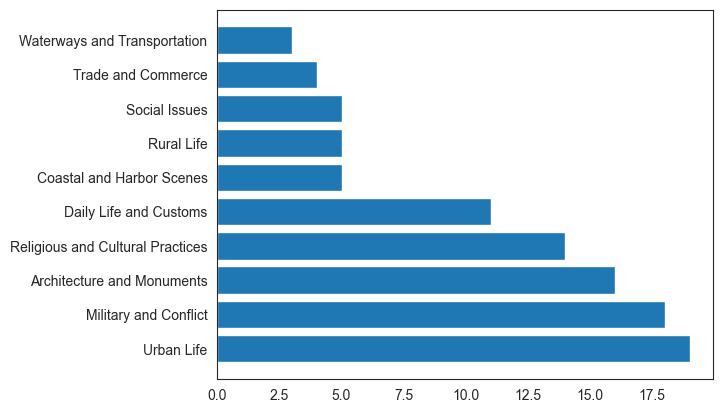

In [13]:
import matplotlib.pyplot as plt

group = df_to_save.groupby("class_name").count()["description"]
group = group.sort_values(ascending=False)
plt.barh(group.index, group.values)

In [14]:
data = pd.DataFrame(zip(group.index.tolist(), group.values.tolist()), columns=["Cats", "Num"])

In [22]:
df_to_save[df_to_save["class_name"] == "Religious and Cultural Practices"]

,Unnamed: 0,image,description,class,class_name
8,8,9,The photograph shows a long row of seated stat...,3,Religious and Cultural Practices
14,14,15,The photograph shows an older Chinese woman se...,3,Religious and Cultural Practices
19,19,20,The photograph shows the interior of a teahous...,3,Religious and Cultural Practices
21,21,22,"The image shows a young woman seated indoors, ...",3,Religious and Cultural Practices
26,26,27,"The image shows two large, seated Buddha statu...",3,Religious and Cultural Practices
39,39,40,The photograph depicts a group portrait of a m...,3,Religious and Cultural Practices
49,49,50,The photo shows a large group of Chinese peopl...,3,Religious and Cultural Practices
65,65,66,"The photograph depicts a vast, expansive cemet...",3,Religious and Cultural Practices
86,86,87,The photograph shows a courtyard scene at what...,3,Religious and Cultural Practices
87,87,88,The photograph shows a group of Lama priests g...,3,Religious and Cultural Practices


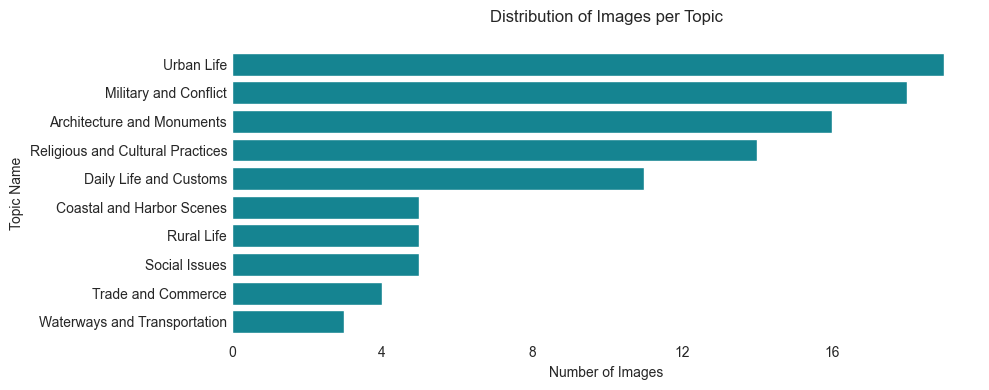

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(10, 4)) 

ax = sns.barplot(x='Num', y='Cats', data=data,
                 color='#0094a6') 

plt.xlabel('Number of Images') 
sns.despine(left=True, bottom=True, top=True, right=True)
plt.ylabel('Topic Name')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.xticks(np.arange(0, 20, 4))
plt.title('Distribution of Images per Topic', pad=20)

plt.tight_layout()
plt.show()